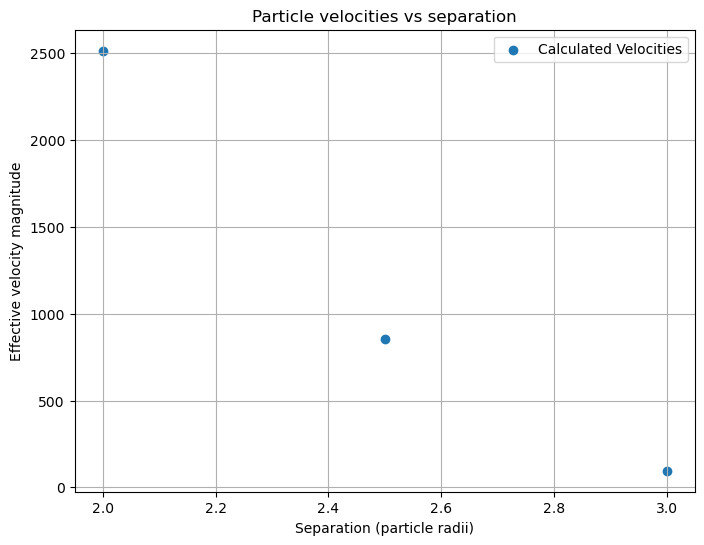

In [11]:
import json

import numpy as np

import matplotlib.pyplot as plt

import os

def load_file(filename):
    
    file = os.path.join("..", "results", f"trajectory_{filename}.json")
    
    with open(file, "r") as f:
        
        data = json.load(f)
        
    return data

def analysis(data, time):
    
    velocities = {}
    
    for particle, positions in data.items():
        
        pos = np.array(positions)
        
        """Randomly chosen frames by me"""
        displacement = pos[45] - pos[23]
        
        total_time = 22 * time
        
        velocities[particle] = displacement/total_time
        
    return velocities

"""x, y and z values stored"""
velocity_dic = {}

res_path = os.path.join("..", "results")

separ_path = os.path.join(res_path, "separations.json")

with open(separ_path, "r") as f:
    
    separations = json.load(f)

time = 0.000001

for se in separations:
    
    loaded_data = load_file(se)
    
    relevant_velo = analysis(loaded_data, time)
    
    velocity_dic[se] = relevant_velo

plt.figure(figsize=(8,6))

for part in ["part1", "part2", "part3"]:
    
    v_list = []
    
    for se in separations:
        
        v_list.append(np.linalg.norm(velocity_dic[se][part]))
    

plt.scatter(separations, v_list, label = "Calculated Velocities")
        
plt.xlabel("Separation (particle radii)")

plt.ylabel("Effective velocity magnitude")

plt.title("Particle velocities vs separation")

plt.legend()

plt.grid(True)

plt.savefig("Analysis_Plot.png")
 
    





